### 最小K个数（美团）--排序

给定一个数组nums，设计一个算法，从该数组中寻找最小的k个数。请按从小到大的顺序返回这k个数。

---

### 不同路径（美团）--动态规划

一个机器人位于一个 m x n 网格的左上角 （起始点在下图中标记为 “Start” ）。

机器人每次只能向下或者向右移动一步。机器人试图达到网格的右下角（在下图中标记为 “Finish” ）。

问总共有多少条不同的路径？

---

### 不同路径2--动态规划
给定一个 m x n 的整数数组 grid。一个机器人初始位于 左上角（即 grid[0][0]）。机器人尝试移动到 右下角（即 grid[m - 1][n - 1]）。机器人每次只能向下或者向右移动一步。

网格中的障碍物和空位置分别用 1 和 0 来表示。机器人的移动路径中不能包含 任何 有障碍物的方格。

返回机器人能够到达右下角的不同路径数量。

测试用例保证答案小于等于 2 * 109。

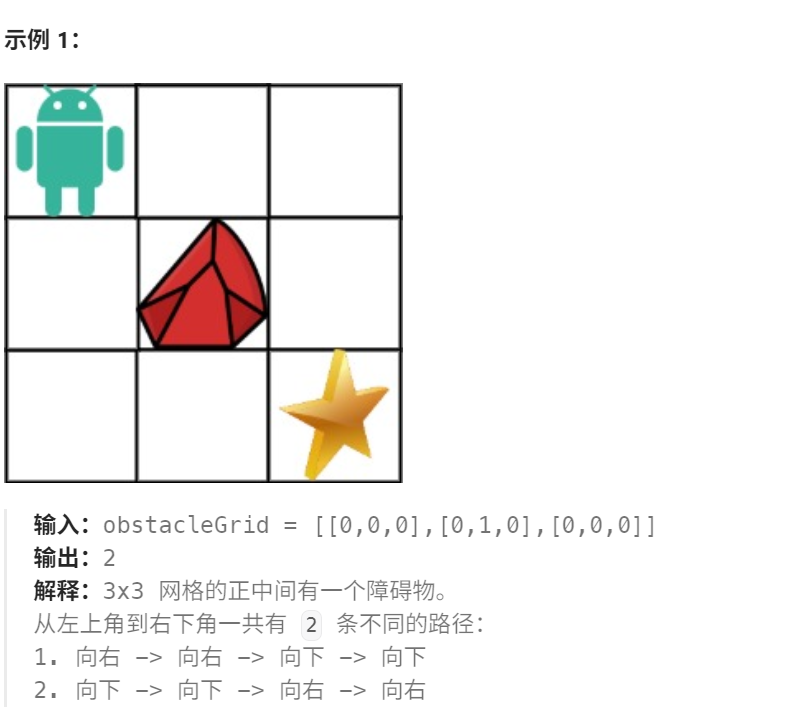

---

### 乘积最大子数组（快手）
给你一个整数数组 nums ，请你找出数组中乘积最大的非空连续 子数组（该子数组中至少包含一个数字），并返回该子数组所对应的乘积

---

### 数组中的第K个最大元素--快速选择

给定整数数组 nums 和整数 k，请返回数组中第 k 个最大的元素。

请注意，你需要找的是数组排序后的第 k 个最大的元素，而不是第 k 个不同的元素。

你必须设计并实现时间复杂度为 O(n) 的算法解决此问题。

---

### 会议室2

给你一个会议时间安排的数组 intervals ，每个会议时间都会包括开始和结束的时间 intervals[i] = [starti, endi] ，返回 所需会议室的最小数量 。
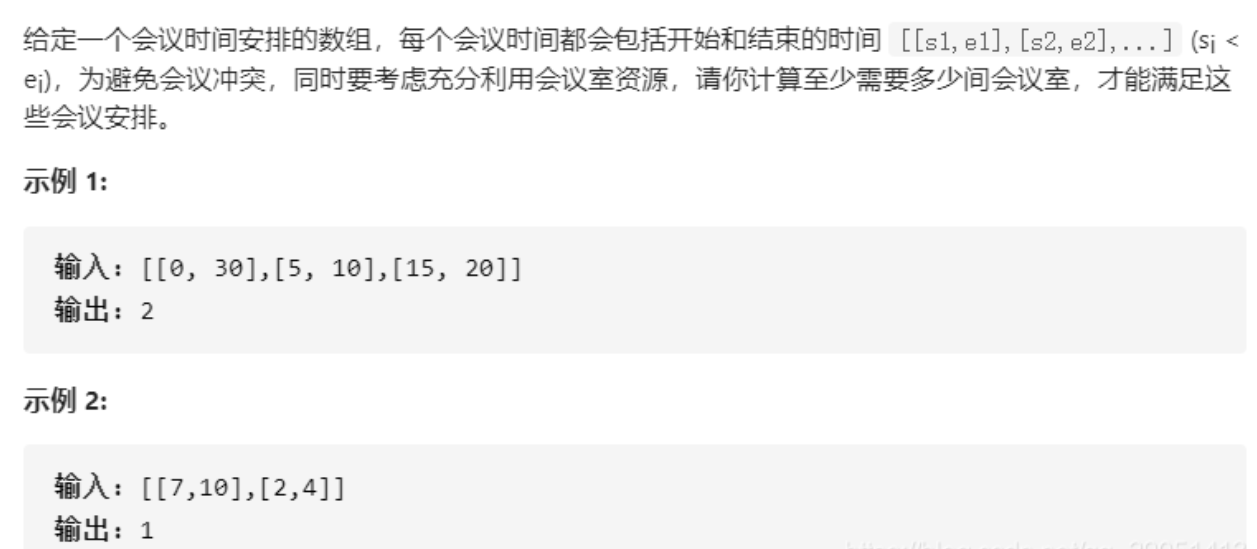

---

In [2]:
import heapq
from typing import List

class Solution:
    def minMeetingRooms(self, intervals: List[List[int]]) -> int:
        """
        目标：给定一组会议 [start, end)，求最少需要多少间会议室（同一时刻 end==start 不冲突）。
        方法：最小堆（小根堆）按“结束时间”管理当前在开的会议；堆大小即并发会议数。
        """

        if not intervals:
            return 0

        # 1) 先按开始时间排序，保证按时间线从早到晚处理
        intervals.sort(key=lambda x: x[0])

        # Python 的 heapq 是“最小堆”：
        # - 以“列表(list)”为底层结构，但必须用 heapq 的 API 维护堆序

        # - 堆顶 heap[0] 永远是“最小元素”（本题是“最早结束时间”的会议）
        heap: List[int] = []   # 仅存“正在进行的会议”的结束时间 end
        max_rooms = 0          # 历史最大堆大小 = 最少需要的会议室

        for s, e in intervals:  # 可迭代解包：每次拿到一个会议的开始 s、结束 e


            # - 注意使用 while 而不是 if：可能同时空出多个房间，应全部释放
            while heap and heap[0] <= s:

                #   * 含义：弹出并返回“最小元素”（本题是最早结束的会议的结束时间）

                #   * 内部机制：把堆顶与“最后一个元素”交换，弹出最后一个O(1)， 
                #               再执行一次“下滤/下沉（sift-down）”恢复堆序O(log k)。
                heapq.heappop(heap)

            # 3) 为当前会议占用一个房间（或复用刚释放的房间）——把它的结束时间压入堆

            #   * 含义：插入一个新结束时间 e

            #   * 内部机制：先把 e 追加到列表末尾（O(1) 追加），
            #               再执行一次“上滤/上浮（sift-up/percolate-up）”把它提到正确位置O(log k)。
            heapq.heappush(heap, e)

            # 4) 堆里元素个数 = 当前时刻在开的会议数（并发数）
            #    历史最大并发数 = 需要的最少会议室
            max_rooms = max(max_rooms, len(heap))

        return max_rooms

---

### 解码方法（腾讯）

一条包含字母 A-Z 的消息通过以下映射进行了 编码 ：

"1" -> 'A'

"2" -> 'B'

...

"25" -> 'Y'

"26" -> 'Z'

然而，在 解码 已编码的消息时，你意识到有许多不同的方式来解码，因为有些编码被包含在其它编码当中（"2" 和 "5" 与 "25"）。

例如，"11106" 可以映射为：

"AAJF" ，将消息分组为 (1, 1, 10, 6)
"KJF" ，将消息分组为 (11, 10, 6)
消息不能分组为  (1, 11, 06) ，因为 "06" 不是一个合法编码（只有 "6" 是合法的）。
注意，可能存在无法解码的字符串。

给你一个只含数字的 非空 字符串 s ，请计算并返回 解码 方法的 总数 。如果没有合法的方式解码整个字符串，返回 0。

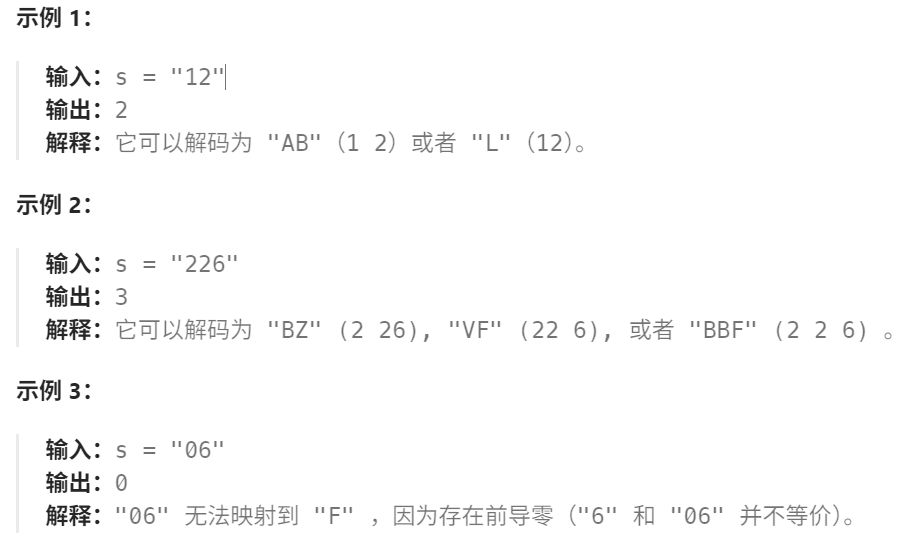

核心思想

- （1）当加入的一个数是0，那么dp[i]=dp[i-2]（因为i-1字符需要和0绑定） 或者就是0种编码方法。
- （2）当加入的一个数是1...9，且只能单独编码时，dp[i]=dp[i-1]。
- （3）当加入的一个数是1...9，可以与前面的组合编码，dp[i] = dp[i-1] + dp[i-2] 

In [ ]:
class Solution:
    def numDecodings(self, s: str) -> int:
        n = len(s)
        if  not s or s[0] == '0':
            return 0

        dpi_2, dpi_1 = 1, 1
        
        for i in range(1, n):
            encoder_num = 0
            if s[i] != '0':
                encoder_num += dpi_1
            if s[i-1] == '1' or (s[i-1] == '2' and s[i] < '7'):
                encoder_num += dpi_2
            if encoder_num == 0:
                return 0
            dpi_2, dpi_1 = dpi_1, encoder_num

        return dpi_1

### 二叉树节点染色的最大权值问题(字节)
给定一个整数数组 nums，用来按层序（level order）表示一棵二叉树。

数组规则如下：

nums[i] 表示编号为 i 的节点的权重。

若 nums[i] 为 null（或某特殊标记），表示该位置不存在节点。

对于任意下标 i：

左子节点下标为 2*i + 1

右子节点下标为 2*i + 2

若子节点下标越界或该位置为 null，则该子节点不存在。

现在你可以对若干节点进行“染色”。

染色约束：

若某节点被染色，则它的父节点不能被染色；

若某节点被染色，则它的左右子节点不能被染色；

兄弟节点之间没有限制。

目标：

在满足上述约束的前提下，选择若干节点，使得被染色节点的权重之和最大。

返回这个最大值。

核心思路

假设：

left = (L0, L1)
right = (R0, R1)

那么：

L0 = 不选左孩子时的最大值
L1 = 选左孩子时的最大值
R0 = 不选右孩子时的最大值
R1 = 选右孩子时的最大值

状态转移

情况1：选当前节点

如果你选当前节点：

那么左右孩子都不能选。

所以：

choose = 当前权重 + L0 + R0

因为：

只能拿“不选孩子”的值。

情况2：不选当前节点

如果你不选当前节点：

左右孩子可以自由选择（选或不选）

所以：

not_choose = max(L0, L1) + max(R0, R1)

In [1]:
from typing import List, Optional

class Solution:
    def maxColorValue(self, nums: List[Optional[int]]) -> int:
        n = len(nums)
        def dfs(i: int):
            """
            返回:
            (not_choose, choose)
            not_choose: 不选当前节点的最大值
            choose: 选当前节点的最大值
            """
            
            # 越界 或 节点为空
            if i >= n or nums[i] is None:
                return (0, 0)
            
            # 递归计算左右子节点
            left = dfs(2 * i + 1)
            right = dfs(2 * i + 2)
            
            # 选当前节点
            # 子节点必须不选
            choose = nums[i] + left[0] + right[0]
            
            # 不选当前节点
            # 子节点可以选或不选，取最大
            not_choose = max(left) + max(right)
            
            return (not_choose, choose)
        
        # 根节点开始
        result = dfs(0)
        
        # 最终可以选根，也可以不选根
        return max(result)
nums = [3,2,3,None,3,None,1]
print(Solution().maxColorValue(nums))

7


---

### 代码infoNCE的函数计算公式（字节）

In [ ]:
import torch
import torch.nn.functional as F
def infoNCE(user_emb, item_emb, tempreture = 0.5):
    B, D = user_emb.shape
    # 归一化
    user_emb = F.normalize(user_emb, dim = -1)
    item_emb = F.normalize(item_emb, dim = -1)
    # 相似矩阵
    sim = torch.matmul(user_emb, item_emb.transpose(0, 1)) / tempreture
    # 标签
    label = torch.arange(B)
    # 多类交叉熵计算
    loss = F.cross_entropy(sim, label) # Compute the cross entropy loss between input logits and target.
    return loss
user_emb = torch.tensor([[1.1, 24.0, 5.9], [3.3, 9.2, 32.1], [12.1, 11.1, 15.3], [0.8, 0.1, 0.4]])
item_emb = torch.tensor([[1.1, 24.0, 5.9], [3.3, 9.2, 32.1], [12.1, 11.1, 15.3], [0.8, 0.1, 0.4]])
print(infoNCE(user_emb, item_emb, 1))

归一化user_emb后
tensor([[0.0445, 0.9701, 0.2385],
        [0.0983, 0.2742, 0.9566],
        [0.5391, 0.4946, 0.6817],
        [0.8889, 0.1111, 0.4444]])
归一化item_emb后
tensor([[0.0445, 0.9701, 0.2385],
        [0.0983, 0.2742, 0.9566],
        [0.5391, 0.4946, 0.6817],
        [0.8889, 0.1111, 0.4444]])
tensor([[1.0000, 0.4985, 0.6664, 0.2533],
        [0.4985, 1.0000, 0.8408, 0.5431],
        [0.6664, 0.8408, 1.0000, 0.8372],
        [0.2533, 0.5431, 0.8372, 1.0000]])
tensor([0, 1, 2, 3])
tensor(1.1176)


---

### 121. 买卖股票的最佳时机(字节)

给定一个数组 prices ，它的第 i 个元素 prices[i] 表示一支给定股票第 i 天的价格。

你只能选择 某一天 买入这只股票，并选择在 未来的某一个不同的日子 卖出该股票。设计一个算法来计算你所能获取的最大利润。

返回你可以从这笔交易中获取的最大利润。如果你不能获取任何利润，返回 0 

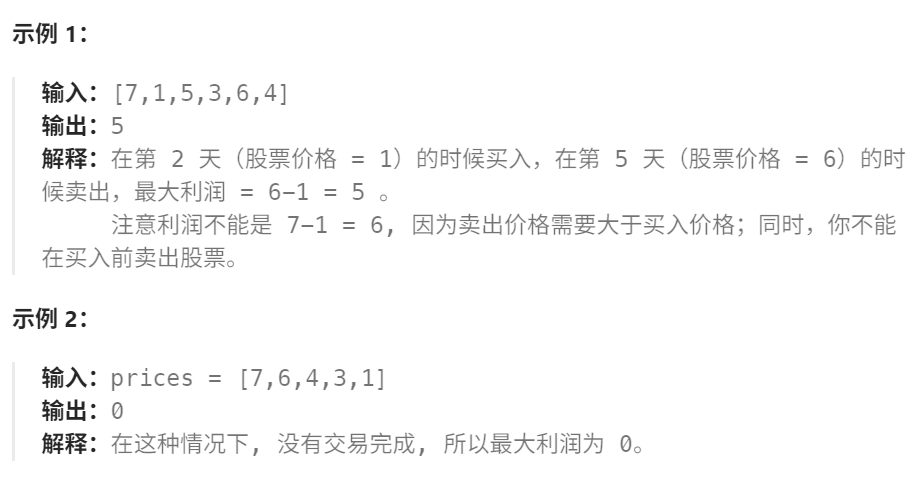


核心思想

在遍历到第 i 天时，
假设第 i 天卖出，最大利润是多少？

利润 = 当前价格 − 之前某一天的最低价格

因此算法维护两个量：

cur_min_price：到当前为止出现过的最低价格（即最优买入点）。

max_profit：到当前为止能获得的最大利润。

一次遍历 + 动态维护历史最低价。


In [2]:
from typing import List
class Solution:
    def maxProfit(self, prices: List[int]) -> int:
        n = len(prices)
        cur_min_price = prices[0]
        max_profit = 0
        for i in range(1, n):
            cur_min_price = min(cur_min_price, prices[i])
            max_profit = max(max_profit, prices[i] - cur_min_price)
        return max_profit
prices = [7, 1, 5, 3, 6, 4]
print(Solution().maxProfit(prices))

5


时间复杂度 O(n)

空间复杂度 O(1)

---